# Exploratory Data Analysis

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import gc
from collections import Counter
import os


from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

# Change with your own roots
PROJECT_ROOT = "/content/drive/MyDrive/dataset"
print("PROJECT_ROOT:", PROJECT_ROOT)

PROJECT_ROOT: /content/drive/MyDrive/dataset


In [ ]:
# Support functions
def plot_label_distribution(df, title):
    counts = df["Is Laundering"].value_counts()
    rates = df["Is Laundering"].value_counts(normalize=True)

    print(counts)
    print()
    print(rates)

    plt.figure()
    counts.plot(kind="bar")
    plt.title(title)
    plt.ylabel("Count")
    plt.show()

def null_summary(df):
    null_counts = df.isna().sum()

    summary = pd.DataFrame({
        "null_count": null_counts,
    })

    return summary[summary["null_count"] > 0]

def duplicate_check(df):
    total = len(df)
    dup_all = df.duplicated().sum()

    return {
        "total_rows": total,
        "duplicate_rows": dup_all,
        "duplicate_rate": dup_all / total
    }

def timestamp_summary(df, time_col="Timestamp"):
    ts = pd.to_datetime(df[time_col], errors="coerce")

    return {
        "min_time": ts.min(),
        "max_time": ts.max(),
        "null_timestamps": ts.isna().sum()
    }

## Dataset

In [ ]:
# change for dataset
dataset = "/LI-Small_Trans.csv"

df = pd.read_csv(PROJECT_ROOT+dataset)
df.head()

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,2022/09/01 00:08,11,8000ECA90,11,8000ECA90,3195403.00,US Dollar,3195403.00,US Dollar,Reinvestment,0
1,2022/09/01 00:21,3402,80021DAD0,3402,80021DAD0,1858.96,US Dollar,1858.96,US Dollar,Reinvestment,0
2,2022/09/01 00:00,11,8000ECA90,1120,8006AA910,592571.00,US Dollar,592571.00,US Dollar,Cheque,0
3,2022/09/01 00:16,3814,8006AD080,3814,8006AD080,12.32,US Dollar,12.32,US Dollar,Reinvestment,0
4,2022/09/01 00:00,20,8006AD530,20,8006AD530,2941.56,US Dollar,2941.56,US Dollar,Reinvestment,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6924049 entries, 0 to 6924048
Data columns (total 11 columns):
 #   Column              Dtype  
---  ------              -----  
 0   Timestamp           object 
 1   From Bank           int64  
 2   Account             object 
 3   To Bank             int64  
 4   Account.1           object 
 5   Amount Received     float64
 6   Receiving Currency  object 
 7   Amount Paid         float64
 8   Payment Currency    object 
 9   Payment Format      object 
 10  Is Laundering       int64  
dtypes: float64(2), int64(3), object(6)
memory usage: 581.1+ MB


In [ ]:
df.describe(include="all")

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
count,6924049,6.924049e+06,6924049,6.924049e+06,6924049,6.924049e+06,6924049,6.924049e+06,6924049,6924049,6.924049e+06
unique,14533,NaN,681281,NaN,576176,NaN,15,NaN,15,7,NaN
top,2022/09/01 00:22,NaN,10042B660,NaN,10042B660,NaN,US Dollar,NaN,US Dollar,Cheque,NaN
freq,15221,NaN,222037,NaN,1553,NaN,2537242,NaN,2553887,2503158,NaN
mean,NaN,5.938718e+04,NaN,8.441702e+04,NaN,6.324067e+06,NaN,4.676036e+06,NaN,NaN,5.148722e-04
std,NaN,9.051700e+04,NaN,9.064562e+04,NaN,2.105371e+09,NaN,1.544099e+09,NaN,NaN,2.268495e-02
min,NaN,0.000000e+00,NaN,0.000000e+00,NaN,1.000000e-06,NaN,1.000000e-06,NaN,NaN,0.000000e+00
25%,NaN,2.190000e+02,NaN,1.125500e+04,NaN,1.742100e+02,NaN,1.753800e+02,NaN,NaN,0.000000e+00
50%,NaN,1.419500e+04,NaN,2.964000e+04,NaN,1.397620e+03,NaN,1.399440e+03,NaN,NaN,0.000000e+00
75%,NaN,1.106820e+05,NaN,1.480400e+05,NaN,1.229633e+04,NaN,1.222687e+04,NaN,NaN,0.000000e+00


In [ ]:
df['Is Laundering'].unique()

array([0, 1])

## Null & Duplicates

In [ ]:
null_summary(df)

,null_count


In [ ]:
duplicate_check(df)

{'total_rows': 6924049,
 'duplicate_rows': np.int64(8),
 'duplicate_rate': np.float64(1.1553933254949525e-06)}

In [ ]:
# Clean duplicates
print(f"Shape before removing duplicates: {df.shape}")

df = df.drop_duplicates().reset_index(drop=True)

print(f"New shape after removing duplicates: {df.shape}")

Shape before removing duplicates: (6924049, 11)
New shape after removing duplicates: (6924041, 11)


In [ ]:
# Check for invalid account names
account_cols = [c for c in df.columns if "account" in c.lower()]

if len(account_cols) == 0:
    print("No account columns found (no columns containing 'account').")
else:
    # Basic validity rules:
    # - not null
    # - not empty/whitespace
    # - only allows letters, digits, underscore, hyphen, dot (customize if needed)
    allowed_pattern = r"^[A-Za-z0-9_.-]+$"

    invalid_summary = {}

    for c in account_cols:
        s = df[c].astype("string")

        is_null = s.isna()
        is_empty = s.str.strip().eq("")
        bad_chars = ~s.str.match(allowed_pattern, na=False)

        invalid_mask = is_null | is_empty | bad_chars
        invalid_count = int(invalid_mask.sum())

        invalid_summary[c] = {
            "invalid_count": invalid_count,
            "null_count": int(is_null.sum()),
            "empty_count": int(is_empty.sum()),
            "bad_char_count": int(bad_chars.sum())
        }

        print(f"\n[{c}] invalid rows: {invalid_count}")
        print("  null:", invalid_summary[c]["null_count"])
        print("  empty:", invalid_summary[c]["empty_count"])
        print("  bad_chars:", invalid_summary[c]["bad_char_count"])

        if invalid_count > 0:
            examples = df.loc[invalid_mask, c].astype("string").head(10).tolist()
            print("  examples:", examples)

    print("\nChecked account columns:", account_cols)


[Account] invalid rows: 0
  null: 0
  empty: 0
  bad_chars: 0

[Account.1] invalid rows: 0
  null: 0
  empty: 0
  bad_chars: 0

Checked account columns: ['Account', 'Account.1']


In [ ]:
# Check for invalid transaction values

value_cols = [c for c in df.columns if any(k in c.lower() for k in ["amount", "value"])]

if len(value_cols) == 0:
    print("No transaction value columns found (no columns containing 'amount' or 'value').")
else:
    for c in value_cols:
        x = pd.to_numeric(df[c], errors="coerce")

        is_nan = x.isna()
        is_inf = np.isinf(x.to_numpy(dtype=float, copy=False))
        is_neg = x < 0
        is_zero = x == 0

        invalid_mask = is_nan | is_inf | is_neg

        print(f"\n[{c}]")
        print("  total rows:", len(df))
        print("  NaN after numeric coercion:", int(is_nan.sum()))
        print("  inf:", int(is_inf.sum()))
        print("  negative:", int(is_neg.sum()))
        print("  zero:", int(is_zero.sum()))
        print("  invalid (NaN/inf/negative):", int(invalid_mask.sum()))

        if int(invalid_mask.sum()) > 0:
            example_rows = df.loc[invalid_mask, [c]].head(10)
            print("  first invalid examples:")
            display(example_rows)

    print("\nChecked value columns:", value_cols)


[Amount Received]
  total rows: 6924041
  NaN after numeric coercion: 0
  inf: 0
  negative: 0
  zero: 0
  invalid (NaN/inf/negative): 0

[Amount Paid]
  total rows: 6924041
  NaN after numeric coercion: 0
  inf: 0
  negative: 0
  zero: 0
  invalid (NaN/inf/negative): 0

Checked value columns: ['Amount Received', 'Amount Paid']


## Distributions

Is Laundering
0    6920476
1       3565
Name: count, dtype: int64

Is Laundering
0    0.999485
1    0.000515
Name: proportion, dtype: float64


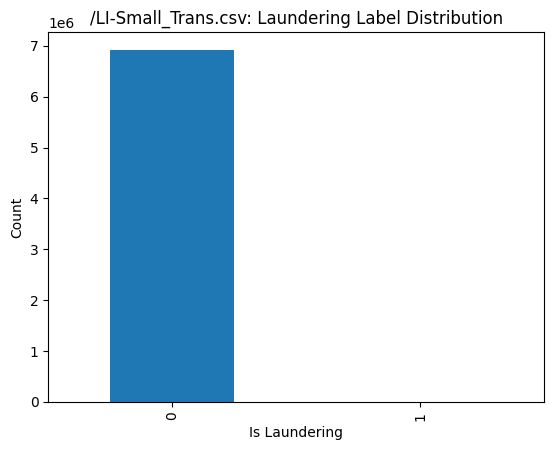

In [ ]:
plot_label_distribution(df, dataset + ": Laundering Label Distribution")

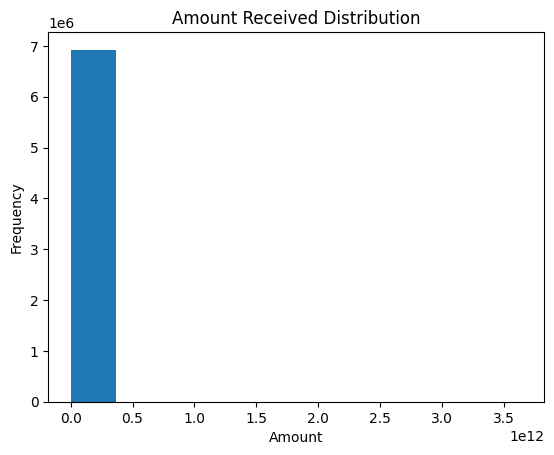

In [ ]:
plt.hist(df["Amount Received"])
plt.title("Amount Received Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

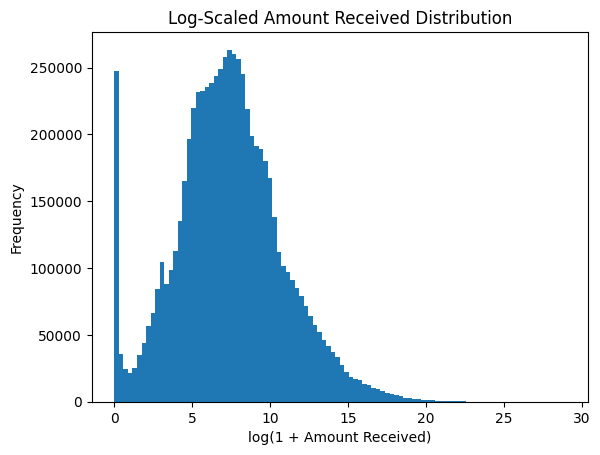

In [ ]:
amt = pd.to_numeric(df["Amount Received"], errors="coerce")
df["Log Amount Received"] = np.log1p(amt)

plt.figure()
plt.hist(df["Log Amount Received"], bins=100)
plt.title("Log-Scaled Amount Received Distribution")
plt.xlabel("log(1 + Amount Received)")
plt.ylabel("Frequency")
plt.show()

In [ ]:
ct = pd.crosstab(
    df["Payment Currency"],
    df["Is Laundering"]
)

ct["total"] = ct[0] + ct[1]
ct["laundered_%"] = ct[1] / ct["total"] * 100

ct.sort_values("laundered_%", ascending=False)

Is Laundering,0,1,total,laundered_%
Payment Currency,,,,
Euro,1594834,1025,1595859,0.064229
US Dollar,2552430,1456,2553886,0.057011
Canadian Dollar,175983,86,176069,0.048844
Saudi Riyal,257833,115,257948,0.044583
Ruble,88453,39,88492,0.044072
Mexican Peso,84704,37,84741,0.043662
Yen,210039,86,210125,0.040928
Swiss Franc,138195,56,138251,0.040506
UK Pound,99628,40,99668,0.040133


In [ ]:
numeric_cols = df.select_dtypes(include=["int64", "float64"])

numeric_cols.corr()

,From Bank,To Bank,Amount Received,Amount Paid,Is Laundering,Log Amount Received
From Bank,1.000000,0.290109,-0.000460,-0.000323,-0.004350,-0.073133
To Bank,0.290109,1.000000,-0.000817,-0.000517,-0.005846,-0.041846
Amount Received,-0.000460,-0.000817,1.000000,0.739589,-0.000029,0.014678
Amount Paid,-0.000323,-0.000517,0.739589,1.000000,-0.000015,0.014263
Is Laundering,-0.004350,-0.005846,-0.000029,-0.000015,1.000000,0.006723
Log Amount Received,-0.073133,-0.041846,0.014678,0.014263,0.006723,1.000000


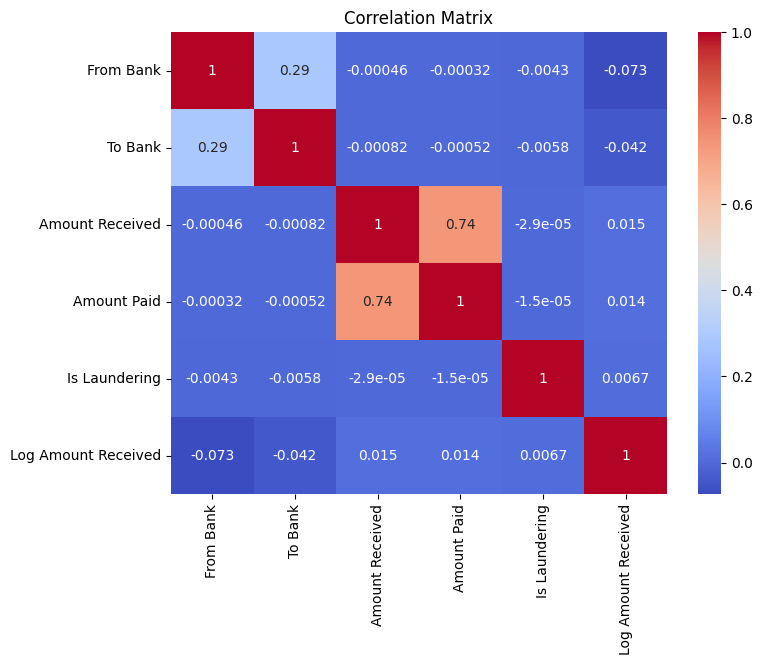

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

## Datetime Preprocessing

In [ ]:
timestamp_summary(df)

{'min_time': Timestamp('2022-09-01 00:00:00'),
 'max_time': Timestamp('2022-09-17 15:28:00'),
 'null_timestamps': np.int64(0)}

In [ ]:
# Setup for date data preprocessing

TS_COL = "Timestamp"
LABEL_COL = "Is Laundering"

TS_FORMAT = "%Y/%m/%d %H:%M"

# Use True for Large
USE_STREAMING = False
CHUNKSIZE = 2_000_000

CSV_PATH = PROJECT_ROOT + dataset

def _coerce_label_to_int(series):
    return pd.to_numeric(series.astype(str).str.strip(), errors="coerce").fillna(0).astype(int)


def _time_aggs_from_df(df_in, ts_col=TS_COL, label_col=LABEL_COL, ts_format=TS_FORMAT):
    y = _coerce_label_to_int(df_in[label_col]).to_numpy(dtype=np.int8)

    if ts_format is None:
        ts = pd.to_datetime(df_in[ts_col], errors="coerce")
    else:
        ts = pd.to_datetime(df_in[ts_col], format=ts_format, errors="coerce")

    mask = ts.notna().to_numpy()
    bad_ts = int((~mask).sum())

    ts = ts[mask]
    y = y[mask]

    hour = ts.dt.hour.to_numpy(dtype=np.int16)
    dow = ts.dt.dayofweek.to_numpy(dtype=np.int16)  # Mon=0..Sun=6

    hour_total = np.bincount(hour, minlength=24).astype(np.int64)
    hour_pos   = np.bincount(hour, weights=y, minlength=24).astype(np.int64)

    dow_total = np.bincount(dow, minlength=7).astype(np.int64)
    dow_pos   = np.bincount(dow, weights=y, minlength=7).astype(np.int64)

    idx = dow * 24 + hour
    hd_total = np.bincount(idx, minlength=7*24).reshape(7, 24).astype(np.int64)
    hd_pos   = np.bincount(idx, weights=y, minlength=7*24).reshape(7, 24).astype(np.int64)

    return {
        "hour_total": hour_total, "hour_pos": hour_pos,
        "dow_total": dow_total,   "dow_pos": dow_pos,
        "hd_total": hd_total,     "hd_pos": hd_pos,
        "total_rows": int(mask.sum()),
        "bad_ts": bad_ts
    }


def _time_aggs_streaming(csv_path, chunksize=CHUNKSIZE, ts_col=TS_COL, label_col=LABEL_COL, ts_format=TS_FORMAT):
    hour_total = np.zeros(24, dtype=np.int64)
    hour_pos   = np.zeros(24, dtype=np.int64)

    dow_total  = np.zeros(7, dtype=np.int64)
    dow_pos    = np.zeros(7, dtype=np.int64)

    hd_total   = np.zeros((7, 24), dtype=np.int64)
    hd_pos     = np.zeros((7, 24), dtype=np.int64)

    total_rows = 0
    bad_ts = 0

    usecols = [ts_col, label_col]

    for chunk in pd.read_csv(csv_path, usecols=usecols, chunksize=chunksize):
        total_rows += len(chunk)

        y = _coerce_label_to_int(chunk[label_col]).to_numpy(dtype=np.int8)

        if ts_format is None:
            ts = pd.to_datetime(chunk[ts_col], errors="coerce")
        else:
            ts = pd.to_datetime(chunk[ts_col], format=ts_format, errors="coerce")

        mask = ts.notna().to_numpy()
        if not mask.all():
            bad_ts += int((~mask).sum())

        ts = ts[mask]
        y  = y[mask]

        hour = ts.dt.hour.to_numpy(dtype=np.int16)
        dow  = ts.dt.dayofweek.to_numpy(dtype=np.int16)

        hour_total += np.bincount(hour, minlength=24)
        hour_pos   += np.bincount(hour, weights=y, minlength=24).astype(np.int64)

        dow_total += np.bincount(dow, minlength=7)
        dow_pos   += np.bincount(dow, weights=y, minlength=7).astype(np.int64)

        idx = dow * 24 + hour
        flat_total = np.bincount(idx, minlength=7*24).reshape(7, 24)
        flat_pos   = np.bincount(idx, weights=y, minlength=7*24).reshape(7, 24).astype(np.int64)

        hd_total += flat_total
        hd_pos   += flat_pos

    return {
        "hour_total": hour_total, "hour_pos": hour_pos,
        "dow_total": dow_total,   "dow_pos": dow_pos,
        "hd_total": hd_total,     "hd_pos": hd_pos,
        "total_rows": int(total_rows),
        "bad_ts": int(bad_ts)
    }

In [ ]:
if USE_STREAMING:
    agg = _time_aggs_streaming(CSV_PATH, chunksize=CHUNKSIZE, ts_format=TS_FORMAT)
else:
    agg = _time_aggs_from_df(df, ts_format=TS_FORMAT)

hour_total = agg["hour_total"]
hour_pos   = agg["hour_pos"]
dow_total  = agg["dow_total"]
dow_pos    = agg["dow_pos"]
hd_total   = agg["hd_total"]
hd_pos     = agg["hd_pos"]

print("Temporal EDA for:", dataset)
print("Rows used (valid timestamps):", agg["total_rows"])
print("Bad/unparsed timestamps:", agg["bad_ts"])
print("Overall laundering rate:", float(hour_pos.sum() / max(hour_total.sum(), 1)))

Temporal EDA for: /LI-Small_Trans.csv
Rows used (valid timestamps): 6924041
Bad/unparsed timestamps: 0
Overall laundering rate: 0.0005148727455542219


In [ ]:
hour_df = pd.DataFrame({
    "hour": np.arange(24),
    "tx_count": hour_total,
    "laundering_count": hour_pos,
    "laundering_rate": hour_pos / np.maximum(hour_total, 1)
})

dow_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
dow_df = pd.DataFrame({
    "dow": np.arange(7),
    "day": dow_names,
    "tx_count": dow_total,
    "laundering_count": dow_pos,
    "laundering_rate": dow_pos / np.maximum(dow_total, 1)
})

hd_rate = hd_pos / np.maximum(hd_total, 1)

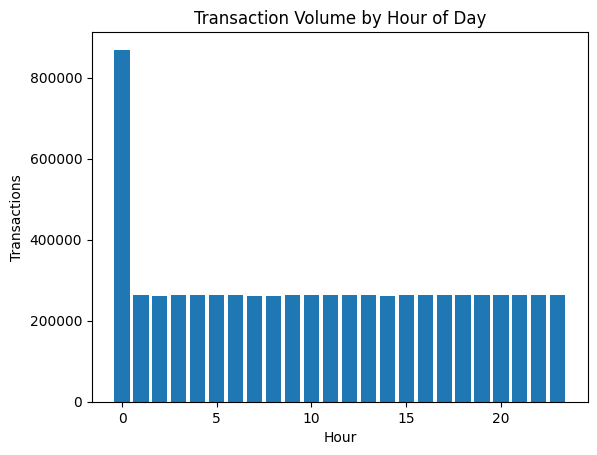

In [ ]:
plt.figure()
plt.bar(hour_df["hour"], hour_df["tx_count"])
plt.title("Transaction Volume by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Transactions")
plt.show()

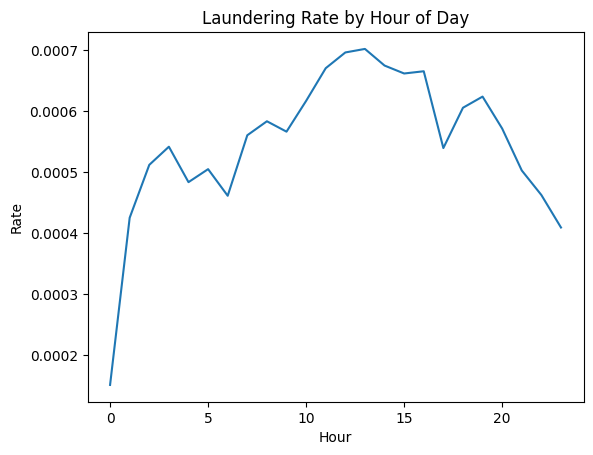

In [ ]:
plt.figure()
plt.plot(hour_df["hour"], hour_df["laundering_rate"])
plt.title("Laundering Rate by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Rate")
plt.show()

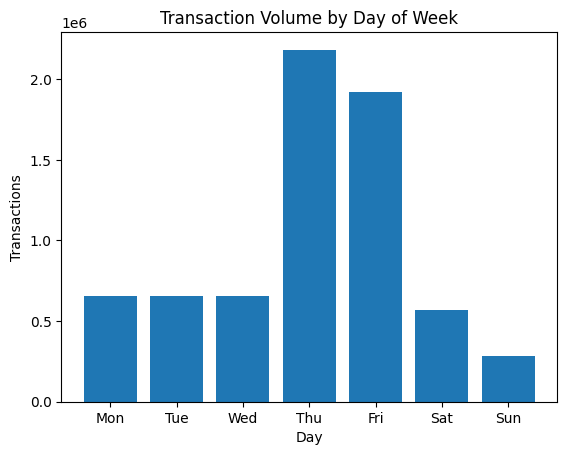

In [ ]:
plt.figure()
plt.bar(dow_df["day"], dow_df["tx_count"])
plt.title("Transaction Volume by Day of Week")
plt.xlabel("Day")
plt.ylabel("Transactions")
plt.show()

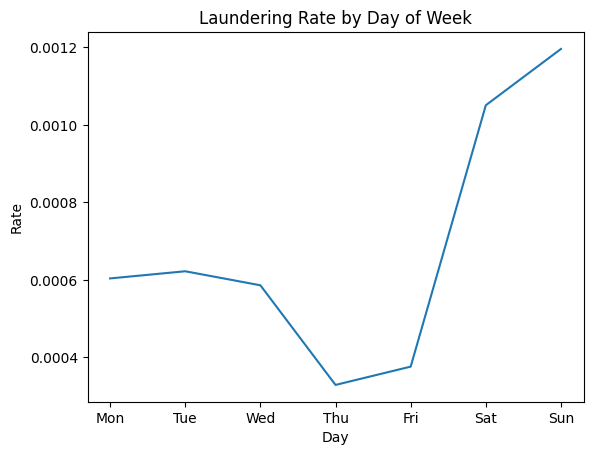

In [ ]:
plt.figure()
plt.plot(dow_df["day"], dow_df["laundering_rate"])
plt.title("Laundering Rate by Day of Week")
plt.xlabel("Day")
plt.ylabel("Rate")
plt.show()

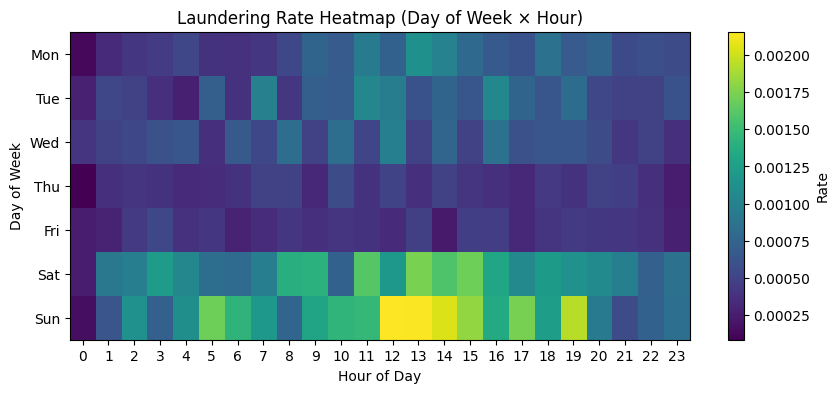

In [ ]:
plt.figure(figsize=(10, 4))
plt.imshow(hd_rate, aspect="auto", interpolation="nearest")
plt.title("Laundering Rate Heatmap (Day of Week × Hour)")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.xticks(np.arange(24), np.arange(24))
plt.yticks(np.arange(7), dow_names)
plt.colorbar(label="Rate")
plt.show()

In [ ]:
if TS_FORMAT is None:
    ts = pd.to_datetime(df[TS_COL], errors="coerce")
else:
    ts = pd.to_datetime(df[TS_COL], format=TS_FORMAT, errors="coerce")

df["_ts"] = ts
df["tx_hour"] = df["_ts"].dt.hour.astype("Int16")
df["tx_dow"] = df["_ts"].dt.dayofweek.astype("Int16")     # Mon=0..Sun=6
df["tx_month"] = df["_ts"].dt.month.astype("Int16")
df["tx_day"] = df["_ts"].dt.day.astype("Int16")
df["tx_date"] = df["_ts"].dt.date                       # python date
df["tx_is_weekend"] = df["tx_dow"].isin([5, 6]).astype("Int8")
df["tx_hour_sin"] = np.sin(2 * np.pi * df["tx_hour"].fillna(0) / 24.0)
df["tx_hour_cos"] = np.cos(2 * np.pi * df["tx_hour"].fillna(0) / 24.0)

In [ ]:
# Final look of the dataset before it is thrown to the models
df.head()

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering,Log Amount Received,_ts,tx_hour,tx_dow,tx_month,tx_day,tx_date,tx_is_weekend,tx_hour_sin,tx_hour_cos
0,2022/09/01 00:08,11,8000ECA90,11,8000ECA90,3195403.00,US Dollar,3195403.00,US Dollar,Reinvestment,0,14.977224,2022-09-01 00:08:00,0,3,9,1,2022-09-01,0,0.0,1.0
1,2022/09/01 00:21,3402,80021DAD0,3402,80021DAD0,1858.96,US Dollar,1858.96,US Dollar,Reinvestment,0,7.528310,2022-09-01 00:21:00,0,3,9,1,2022-09-01,0,0.0,1.0
2,2022/09/01 00:00,11,8000ECA90,1120,8006AA910,592571.00,US Dollar,592571.00,US Dollar,Cheque,0,13.292228,2022-09-01 00:00:00,0,3,9,1,2022-09-01,0,0.0,1.0
3,2022/09/01 00:16,3814,8006AD080,3814,8006AD080,12.32,US Dollar,12.32,US Dollar,Reinvestment,0,2.589267,2022-09-01 00:16:00,0,3,9,1,2022-09-01,0,0.0,1.0
4,2022/09/01 00:00,20,8006AD530,20,8006AD530,2941.56,US Dollar,2941.56,US Dollar,Reinvestment,0,7.987035,2022-09-01 00:00:00,0,3,9,1,2022-09-01,0,0.0,1.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6924041 entries, 0 to 6924040
Data columns (total 21 columns):
 #   Column               Dtype         
---  ------               -----         
 0   Timestamp            object        
 1   From Bank            int64         
 2   Account              object        
 3   To Bank              int64         
 4   Account.1            object        
 5   Amount Received      float64       
 6   Receiving Currency   object        
 7   Amount Paid          float64       
 8   Payment Currency     object        
 9   Payment Format       object        
 10  Is Laundering        int64         
 11  Log Amount Received  float64       
 12  _ts                  datetime64[ns]
 13  tx_hour              Int16         
 14  tx_dow               Int16         
 15  tx_month             Int16         
 16  tx_day               Int16         
 17  tx_date              object        
 18  tx_is_weekend        Int8          
 19  tx_hour_sin          

In [ ]:
df.describe(include="all")

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering,Log Amount Received,_ts,tx_hour,tx_dow,tx_month,tx_day,tx_date,tx_is_weekend,tx_hour_sin,tx_hour_cos
count,6924041,6.924041e+06,6924041,6.924041e+06,6924041,6.924041e+06,6924041,6.924041e+06,6924041,6924041,6.924041e+06,6.924041e+06,6924041,6924041.0,6924041.0,6924041.0,6924041.0,6924041,6924041.0,6924041.0,6924041.0
unique,14533,NaN,681281,NaN,576176,NaN,15,NaN,15,7,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,17,<NA>,<NA>,<NA>
top,2022/09/01 00:22,NaN,10042B660,NaN,10042B660,NaN,US Dollar,NaN,US Dollar,Cheque,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,2022-09-01,<NA>,<NA>,<NA>
freq,15221,NaN,222037,NaN,1553,NaN,2537242,NaN,2553886,2503158,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,1524805,<NA>,<NA>,<NA>
mean,NaN,5.938717e+04,NaN,8.441691e+04,NaN,6.324074e+06,NaN,4.676041e+06,NaN,NaN,5.148727e-04,7.343789e+00,2022-09-05 07:09:11.304066560,10.500517,2.993372,9.0,4.840946,NaN,0.122581,-0.000584,0.087916
min,NaN,0.000000e+00,NaN,0.000000e+00,NaN,1.000000e-06,NaN,1.000000e-06,NaN,NaN,0.000000e+00,9.999995e-07,2022-09-01 00:00:00,0.0,0.0,9.0,1.0,NaN,0.0,-1.0,-1.0
25%,NaN,2.190000e+02,NaN,1.125500e+04,NaN,1.742100e+02,NaN,1.753800e+02,NaN,NaN,0.000000e+00,5.165985e+00,2022-09-02 04:26:00,4.0,2.0,9.0,2.0,NaN,0.0,-0.707107,-0.707107
50%,NaN,1.419500e+04,NaN,2.964000e+04,NaN,1.397630e+03,NaN,1.399450e+03,NaN,NaN,0.000000e+00,7.243248e+00,2022-09-05 12:12:00,10.0,3.0,9.0,5.0,NaN,0.0,0.0,0.258819
75%,NaN,1.106820e+05,NaN,1.480400e+05,NaN,1.229653e+04,NaN,1.222687e+04,NaN,NaN,0.000000e+00,9.417154e+00,2022-09-08 03:04:00,17.0,4.0,9.0,8.0,NaN,0.0,0.707107,0.866025
max,NaN,3.769670e+05,NaN,3.769670e+05,NaN,3.644854e+12,NaN,3.644854e+12,NaN,NaN,1.000000e+00,2.892434e+01,2022-09-17 15:28:00,23.0,6.0,9.0,17.0,NaN,1.0,1.0,1.0


In [ ]:
from datetime import datetime
import os

DRIVE_FOLDER = "/content/drive/MyDrive/dataset_cleaned"
csv_name = "LI-Small_Trans.csv"
csv_path = os.path.join(DRIVE_FOLDER, csv_name)
df.to_csv(csv_path, index=False)

print("Saved CSV to:", csv_path)

Saved CSV to: /content/drive/MyDrive/dataset_cleaned/LI-Small_Trans.csv
